# GRU for Covariance Matrix


In [2]:
import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yfinance as yf
from torch.utils.data import DataLoader

from GRUCovariance import GRUCovariance
from backtesting import run_backtest_suite
from gen_seq_data import SequenceDataset
from plots import plot_loss, plot_var
from risk_metrics import fhs_var_es
from training_functions import (
    StudentTLoss,
    gaussian_nll,
    predict_sigma,
    student_nll,
    train_covariance_model,
    train_val_test_split,
)
from vech import vech

plt.style.use("ggplot")

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

device


'mps'

## Price Data


In [3]:
macro_tickers = [
    "^GSPC",  # Equity (S&P 500)
    "GC=F",   # Gold
    "CL=F",   # Oil
    "^TNX",   # 10Y yield
]

macro_tickers


['^GSPC', 'GC=F', 'CL=F', '^TNX']

In [4]:
macro_data = yf.download(macro_tickers, period="max")
close = macro_data["Close"].copy().dropna()

logret = np.log(close).diff()
logret["^TNX"] = close["^TNX"].diff()
logret = logret.dropna()

logret.head(), logret.tail()


/var/folders/94/8_7g7dqx72760sk83dk1klgc0000gn/T/ipykernel_51675/3766890622.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  macro_data = yf.download(macro_tickers, period="max")
[*********************100%***********************]  4 of 4 completed
/Users/bayesed/.pyenv/versions/3.13.7/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


(Ticker          CL=F      GC=F     ^GSPC   ^TNX
 Date                                           
 2000-08-31 -0.009023  0.015937  0.009993 -0.071
 2000-09-01  0.008424 -0.004682  0.002034 -0.054
 2000-09-05  0.012504 -0.004342 -0.009043  0.008
 2000-09-06  0.033458 -0.005818 -0.009889  0.029
 2000-09-07  0.010814 -0.000730  0.006852  0.037,
 Ticker          CL=F      GC=F     ^GSPC   ^TNX
 Date                                           
 2026-04-13  0.025659 -0.004103  0.010122 -0.020
 2026-04-14 -0.081996  0.017267  0.011714 -0.041
 2026-04-15  0.000110 -0.005195  0.007944  0.026
 2026-04-16  0.036567 -0.003046  0.002607  0.027
 2026-04-17 -0.121579  0.014975  0.011969 -0.063)

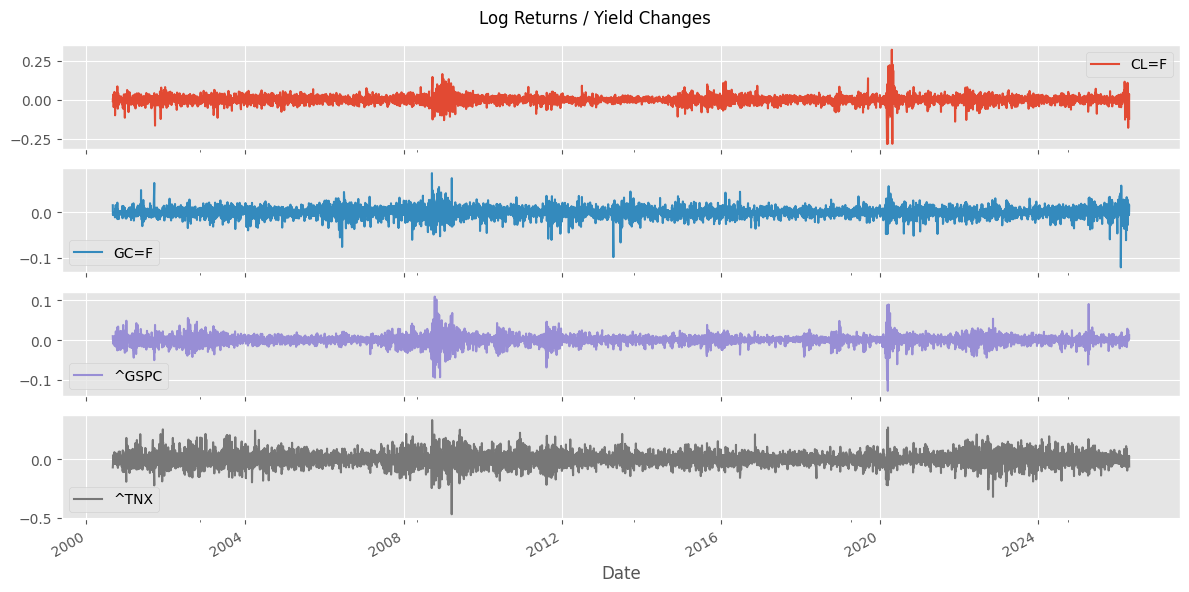

In [5]:
logret.plot(subplots=True, figsize=(12, 6), title="Log Returns / Yield Changes")
plt.tight_layout()


## Feature Engineering


In [6]:
project_dir = Path("/Users/bayesed/Desktop/Studium/Masterthesis/Code/neural_bekk")
data_dir = project_dir / "data"
data_dir.mkdir(exist_ok=True)

run_id = datetime.datetime.now().strftime("%Y-%m-%d")
feature_cols = macro_tickers

R = logret[feature_cols].values.astype(np.float32)
U = R[:, :, None] * R[:, None, :]
cross_returns = vech(torch.tensor(U)).detach().cpu().numpy()

input_data = np.concatenate([logret[feature_cols].values, cross_returns], axis=1)
input_df = pd.DataFrame(
    input_data,
    columns=feature_cols + [f"cross_{i+1}" for i in range(cross_returns.shape[1])],
    index=logret.index,
)

train_df, val_df, test_df = train_val_test_split(input_df)

exports = {
    "logret": logret[feature_cols],
    "train_df": train_df[feature_cols],
    "val_df": val_df[feature_cols],
    "test_df": test_df[feature_cols],
}

input_df.head()


,^GSPC,GC=F,CL=F,^TNX,cross_1,cross_2,cross_3,cross_4,cross_5,cross_6,cross_7,cross_8,cross_9,cross_10
Date,,,,,,,,,,,,,,
2000-08-31,0.009993,0.015937,-0.009023,-0.071,0.000100,0.000159,-0.000090,-0.000709,2.539743e-04,-0.000144,-0.001131,0.000081,0.000641,0.005041
2000-09-01,0.002034,-0.004682,0.008424,-0.054,0.000004,-0.000010,0.000017,-0.000110,2.192223e-05,-0.000039,0.000253,0.000071,-0.000455,0.002916
2000-09-05,-0.009043,-0.004342,0.012504,0.008,0.000082,0.000039,-0.000113,-0.000072,1.884936e-05,-0.000054,-0.000035,0.000156,0.000100,0.000064
2000-09-06,-0.009889,-0.005818,0.033458,0.029,0.000098,0.000058,-0.000331,-0.000287,3.385040e-05,-0.000195,-0.000169,0.001119,0.000970,0.000841
2000-09-07,0.006852,-0.000730,0.010814,0.037,0.000047,-0.000005,0.000074,0.000254,5.324698e-07,-0.000008,-0.000027,0.000117,0.000400,0.001369


In [7]:
pd.DataFrame(
    cross_returns,
    columns=[f"cross_{i+1}" for i in range(cross_returns.shape[1])],
    index=logret.index,
).head()


,cross_1,cross_2,cross_3,cross_4,cross_5,cross_6,cross_7,cross_8,cross_9,cross_10
Date,,,,,,,,,,
2000-08-31,0.000100,0.000159,-0.000090,-0.000709,2.539743e-04,-0.000144,-0.001131,0.000081,0.000641,0.005041
2000-09-01,0.000004,-0.000010,0.000017,-0.000110,2.192223e-05,-0.000039,0.000253,0.000071,-0.000455,0.002916
2000-09-05,0.000082,0.000039,-0.000113,-0.000072,1.884936e-05,-0.000054,-0.000035,0.000156,0.000100,0.000064
2000-09-06,0.000098,0.000058,-0.000331,-0.000287,3.385040e-05,-0.000195,-0.000169,0.001119,0.000970,0.000841
2000-09-07,0.000047,-0.000005,0.000074,0.000254,5.324698e-07,-0.000008,-0.000027,0.000117,0.000400,0.001369


## Scaling & Sequence Dataset


In [8]:
lookback = 60
batchsize = 128
hidden_size = 64
num_layers = 2
dropout = 0.2
epochs = 500
lr = 1e-4

mu = train_df.mean()
sigma = train_df.std()

def normalize(df, mu, sigma, with_std=True):
    if with_std:
        return (df - mu) / sigma
    return df - mu

def scale_back(sigma_scaled, sigma=None, feature_cols=None):
    if sigma is None or feature_cols is None:
        return sigma_scaled
    std_vec = sigma[feature_cols].values.astype(np.float32)
    return sigma_scaled * std_vec[None, :, None] * std_vec[None, None, :]


In [9]:
train_norm = normalize(train_df, mu, sigma, with_std=True)
val_norm = normalize(val_df, mu, sigma, with_std=True)
test_norm = normalize(test_df, mu, sigma, with_std=True)

vol_train_ds = SequenceDataset(
    train_norm.values,
    train_norm[feature_cols].values,
    lookback,
)
vol_val_ds = SequenceDataset(
    val_norm.values,
    val_norm[feature_cols].values,
    lookback,
)
vol_test_ds = SequenceDataset(
    test_norm.values,
    test_norm[feature_cols].values,
    lookback,
)

vol_train_loader = DataLoader(vol_train_ds, batch_size=batchsize, shuffle=True)
vol_train_eval_loader = DataLoader(vol_train_ds, batch_size=batchsize, shuffle=False)
vol_val_loader = DataLoader(vol_val_ds, batch_size=batchsize, shuffle=False)
vol_test_loader = DataLoader(vol_test_ds, batch_size=batchsize, shuffle=False)

len(vol_train_ds), len(vol_val_ds), len(vol_test_ds)


(4431, 903, 903)

## Helper Functions


In [10]:
split_frames = {
    "train": train_df,
    "val": val_df,
    "test": test_df,
}

def fit_gru_model(loss_fn=gaussian_nll, loss_kwargs=None, epochs=epochs, lr=lr):
    k = len(feature_cols) * (len(feature_cols) + 1) // 2
    model = GRUCovariance(
        input_size=len(feature_cols) + k,
        n_assets=len(feature_cols),
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
    )

    model, history = train_covariance_model(
        model,
        vol_train_loader,
        vol_val_loader,
        loss_fn=loss_fn,
        loss_kwargs=loss_kwargs,
        epochs=epochs,
        lr=lr,
        plateau_patience=20,
        device=device,
        scheduler_type="cosine",
    )

    sigma_train_scaled, y_train_scaled = predict_sigma(model, vol_train_eval_loader, device=device)
    sigma_val_scaled, y_val_scaled = predict_sigma(model, vol_val_loader, device=device)
    sigma_test_scaled, y_test_scaled = predict_sigma(model, vol_test_loader, device=device)

    sigma_splits = {
        "train": scale_back(sigma_train_scaled, sigma=sigma, feature_cols=feature_cols),
        "val": scale_back(sigma_val_scaled, sigma=sigma, feature_cols=feature_cols),
        "test": scale_back(sigma_test_scaled, sigma=sigma, feature_cols=feature_cols),
    }
    y_splits = {
        "train": y_train_scaled,
        "val": y_val_scaled,
        "test": y_test_scaled,
    }
    return model, history, sigma_splits, y_splits

def calc_portfolio_variance(df_split, sigma_split, cols, lookback, w):
    idx = df_split.index[lookback:]
    r = df_split.loc[idx, cols].values
    r_p = (w * r).sum(axis=1)
    tmp = sigma_split @ w
    var_p = (w * tmp).sum(axis=1)
    var_p = np.clip(var_p, 1e-12, None)
    vol_p = np.sqrt(var_p)
    return idx, r_p, var_p, vol_p

def make_portfolio_df(idx, rp, varp, volp):
    return pd.DataFrame(
        {
            "r_p": np.asarray(rp, dtype=float),
            "var_p": np.asarray(varp, dtype=float),
            "vol_p": np.asarray(volp, dtype=float),
        },
        index=idx,
    )

def build_portfolio_splits(sigma_splits, w):
    portfolio_splits = {}
    for split_name, df_split in split_frames.items():
        idx, rp, varp, volp = calc_portfolio_variance(
            df_split,
            sigma_splits[split_name],
            feature_cols,
            lookback,
            w,
        )
        portfolio_splits[split_name] = make_portfolio_df(idx, rp, varp, volp)
    return portfolio_splits

def standardized_portfolio_returns(portfolio_df):
    return portfolio_df["r_p"].values / np.clip(portfolio_df["vol_p"].values, 1e-12, None)

def run_fhs_pipeline(portfolio_train, portfolio_val, portfolio_test, alpha=0.01, window=1000):
    z_train = standardized_portfolio_returns(portfolio_train)
    z_val = standardized_portfolio_returns(portfolio_val)
    z_test = standardized_portfolio_returns(portfolio_test)
    z_train_val = np.concatenate([z_train, z_val])

    train_burn_in = min(window, len(z_train) - 1)
    if train_burn_in < 1:
        raise ValueError("Training split is too short for FHS burn-in.")

    var_fhs_test, es_fhs_test, hits_test = fhs_var_es(
        z_hist_init=z_train_val,
        r_oos=portfolio_test["r_p"].values,
        vol_oos=portfolio_test["vol_p"].values,
        alpha=alpha,
        window=window,
    )
    var_fhs_val, es_fhs_val, hit_val = fhs_var_es(
        z_hist_init=z_train,
        r_oos=portfolio_val["r_p"].values,
        vol_oos=portfolio_val["vol_p"].values,
        alpha=alpha,
        window=window,
    )
    var_fhs_train, es_fhs_train, hit_train = fhs_var_es(
        z_hist_init=z_train[:train_burn_in],
        r_oos=portfolio_train["r_p"].iloc[train_burn_in:].values,
        vol_oos=portfolio_train["vol_p"].iloc[train_burn_in:].values,
        alpha=alpha,
        window=window,
    )

    return {
        "z": {
            "train": z_train,
            "val": z_val,
            "test": z_test,
            "train_val": z_train_val,
        },
        "burn_in": train_burn_in,
        "train": {"var": var_fhs_train, "es": es_fhs_train, "hits": hit_train},
        "val": {"var": var_fhs_val, "es": es_fhs_val, "hits": hit_val},
        "test": {"var": var_fhs_test, "es": es_fhs_test, "hits": hits_test},
    }

def plot_fhs_var(portfolio_df, var_fhs, alpha, title, start=0):
    idx = portfolio_df.index[start:]
    returns = portfolio_df["r_p"].iloc[start:].values
    plt.figure(figsize=(12, 4))
    plt.plot(idx, returns, color="black", lw=0.8, label="Portfolio Return")
    plt.plot(idx, var_fhs, "--", color="tab:red", lw=1.2, label=f"FHS {alpha:.1%} VaR (lower)")
    plt.fill_between(idx, var_fhs, np.zeros_like(var_fhs), color="tab:red", alpha=0.08)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


## GRU with Gaussian NLL


Epoch 001 | train NLL 6.620120 | val NLL 9.202990 | lr 1.00e-04
Epoch 002 | train NLL 6.242108 | val NLL 8.481788 | lr 1.00e-04
Epoch 003 | train NLL 5.962687 | val NLL 7.865260 | lr 1.00e-04
Epoch 004 | train NLL 5.710932 | val NLL 7.252253 | lr 1.00e-04
Epoch 005 | train NLL 5.468432 | val NLL 6.687750 | lr 1.00e-04
Epoch 006 | train NLL 5.315238 | val NLL 6.367530 | lr 1.00e-04
Epoch 007 | train NLL 5.229240 | val NLL 6.260157 | lr 1.00e-04
Epoch 008 | train NLL 5.178019 | val NLL 6.175237 | lr 9.99e-05
Epoch 009 | train NLL 5.143832 | val NLL 6.107261 | lr 9.99e-05
Epoch 010 | train NLL 5.132186 | val NLL 6.107941 | lr 9.99e-05
Epoch 011 | train NLL 5.114066 | val NLL 6.041157 | lr 9.99e-05
Epoch 012 | train NLL 5.104637 | val NLL 6.029751 | lr 9.99e-05
Epoch 013 | train NLL 5.092804 | val NLL 6.002381 | lr 9.98e-05
Epoch 014 | train NLL 5.088806 | val NLL 5.968780 | lr 9.98e-05
Epoch 015 | train NLL 5.077558 | val NLL 5.934947 | lr 9.98e-05
Epoch 016 | train NLL 5.071855 | val NLL

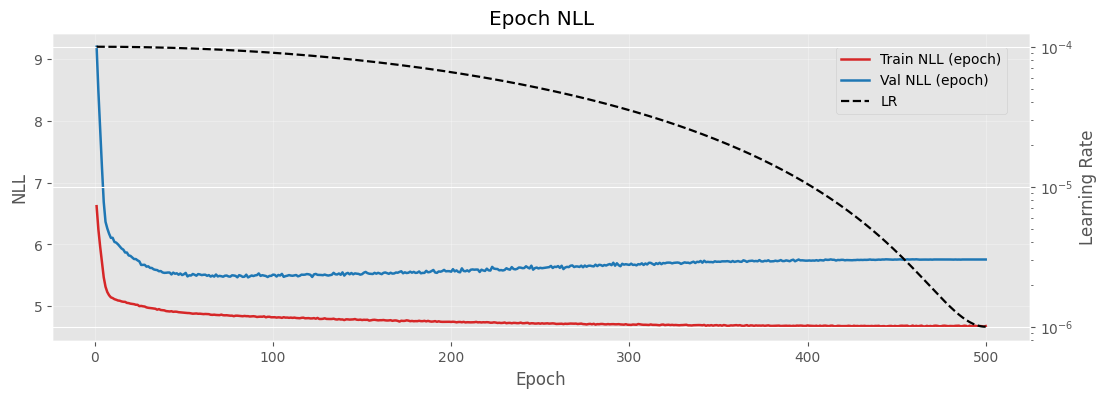

In [11]:
cov_model, hist, sigma_splits, y_splits = fit_gru_model(loss_fn=gaussian_nll)

sigma_train_real = sigma_splits["train"]
sigma_val_real = sigma_splits["val"]
sigma_test_real = sigma_splits["test"]

plot_loss(hist)


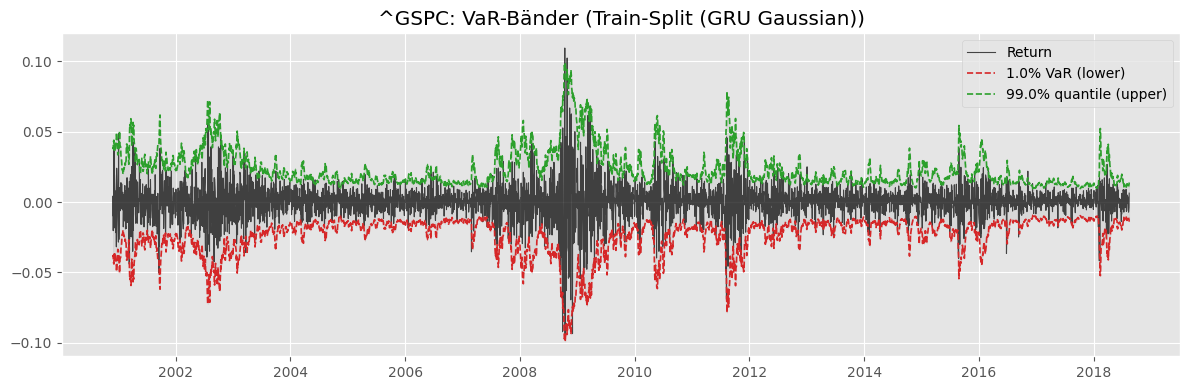

^GSPC: hit rate = 1.535% (target 1.000%)


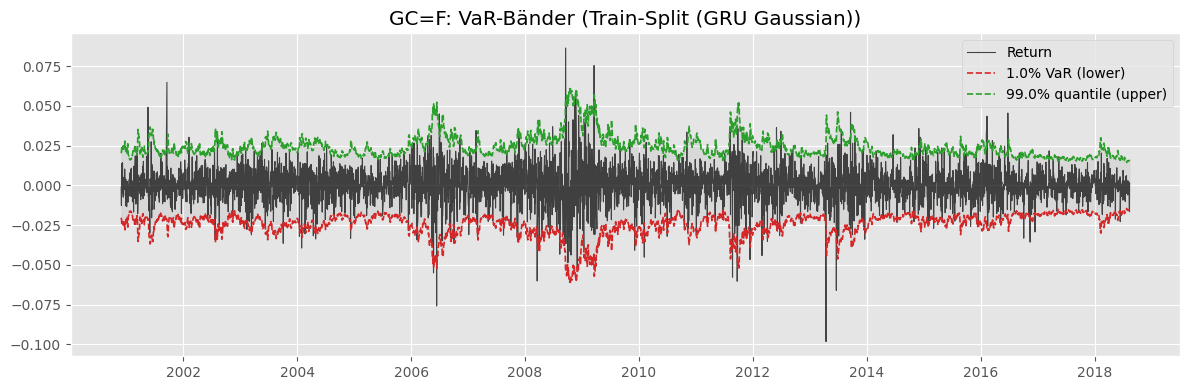

GC=F: hit rate = 1.805% (target 1.000%)


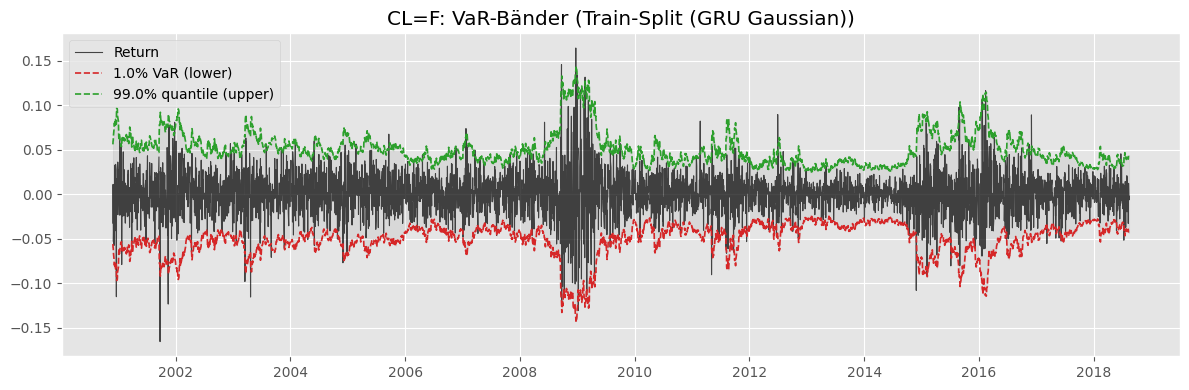

CL=F: hit rate = 1.467% (target 1.000%)


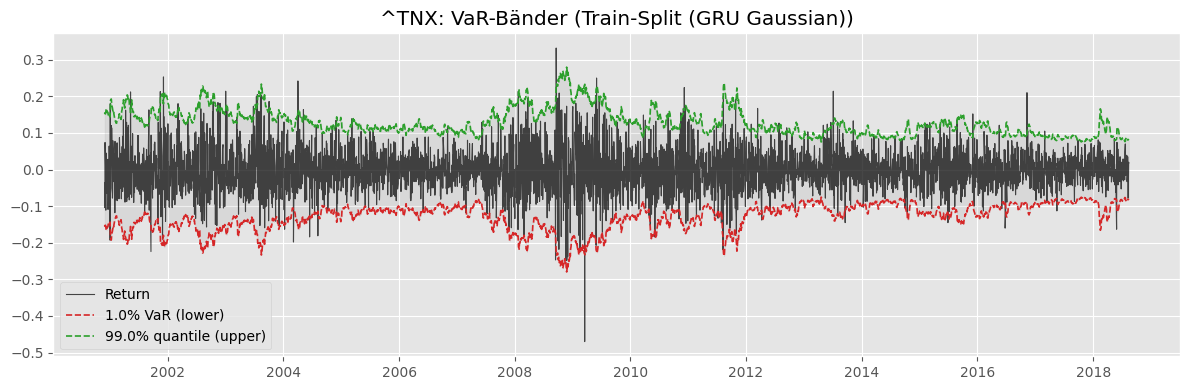

^TNX: hit rate = 0.903% (target 1.000%)


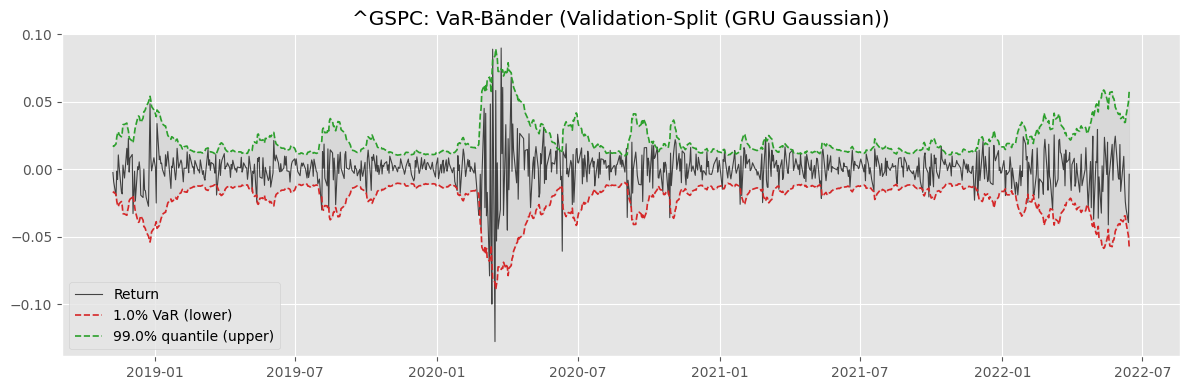

^GSPC: hit rate = 3.544% (target 1.000%)


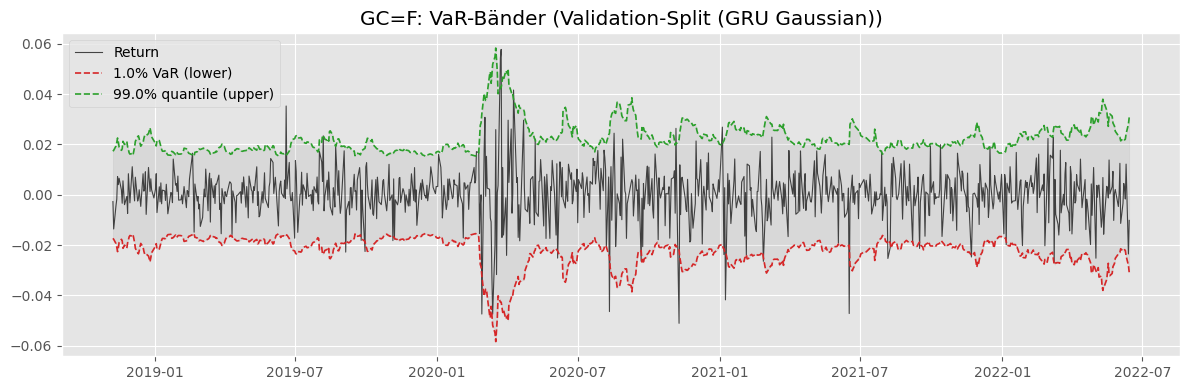

GC=F: hit rate = 2.326% (target 1.000%)


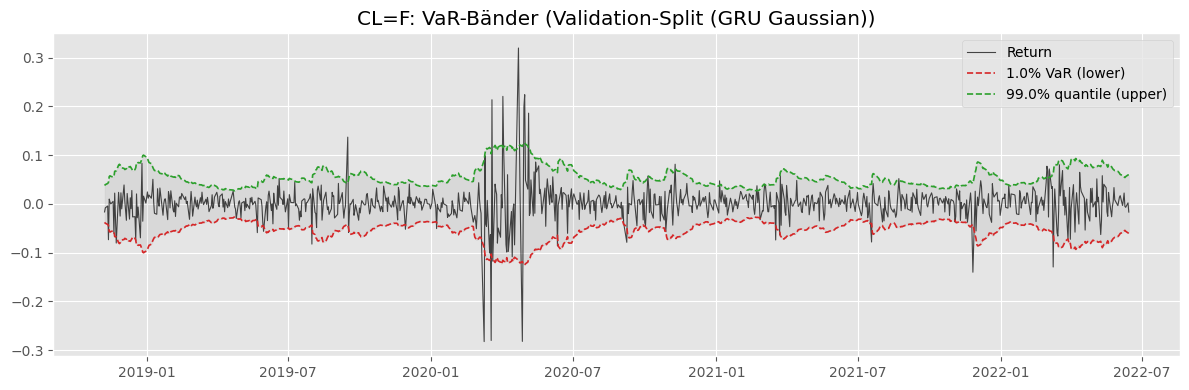

CL=F: hit rate = 3.101% (target 1.000%)


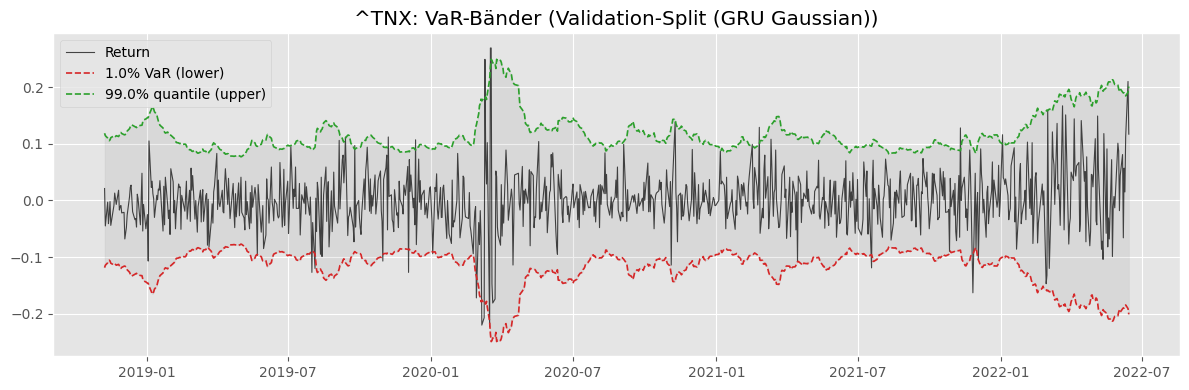

^TNX: hit rate = 1.550% (target 1.000%)


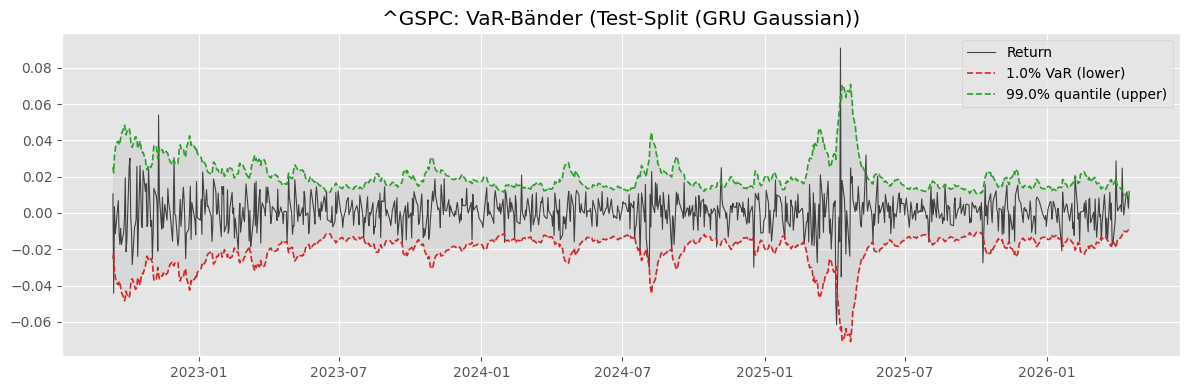

^GSPC: hit rate = 2.658% (target 1.000%)


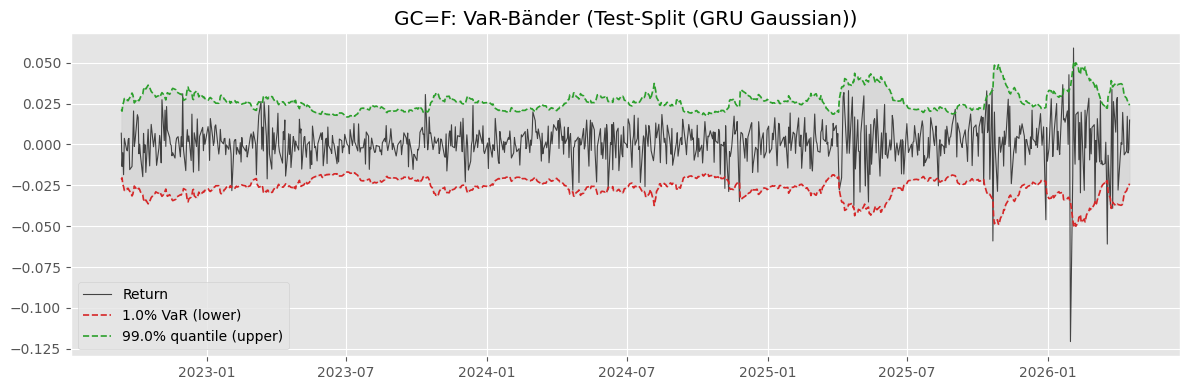

GC=F: hit rate = 1.661% (target 1.000%)


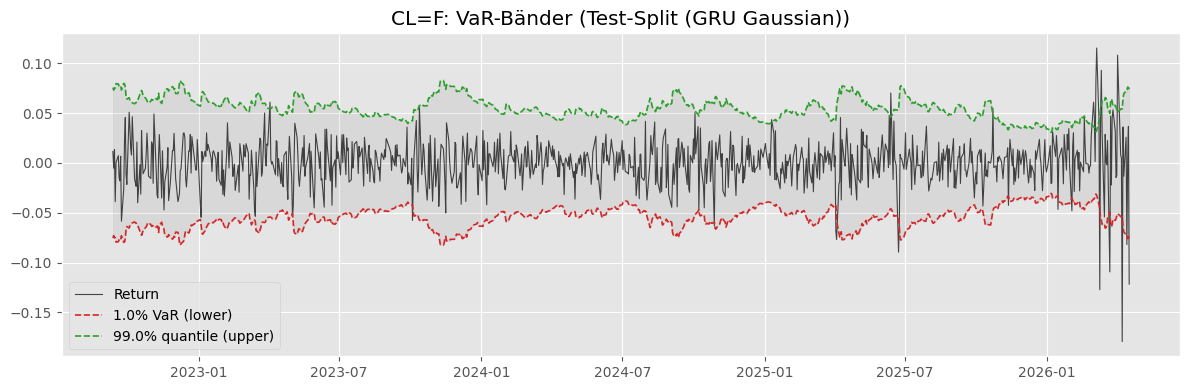

CL=F: hit rate = 1.661% (target 1.000%)


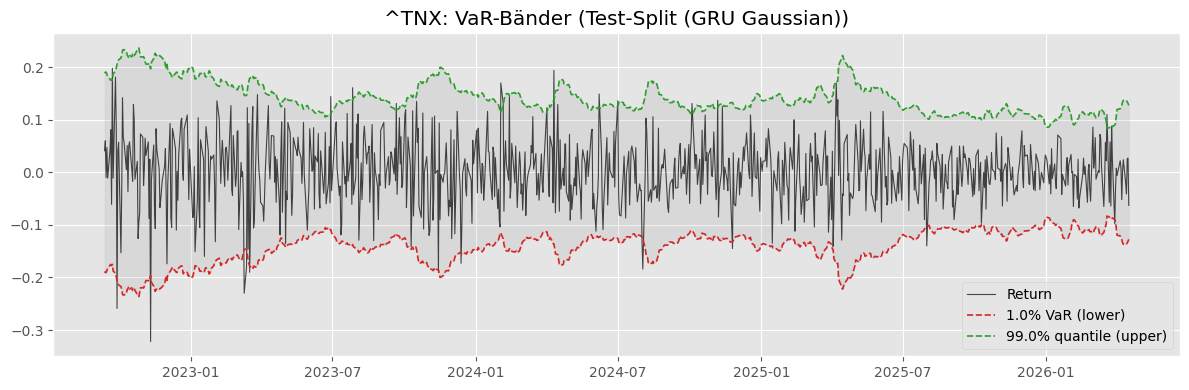

^TNX: hit rate = 1.329% (target 1.000%)


In [12]:
plot_var(alpha=0.01, lookback=lookback, cols=feature_cols, view="Train-Split (GRU Gaussian)", df=train_df, pred_vol=sigma_train_real)
plot_var(alpha=0.01, lookback=lookback, cols=feature_cols, view="Validation-Split (GRU Gaussian)", df=val_df, pred_vol=sigma_val_real)
plot_var(alpha=0.01, lookback=lookback, cols=feature_cols, view="Test-Split (GRU Gaussian)", df=test_df, pred_vol=sigma_test_real)


## Portfolio (Gaussian NLL)


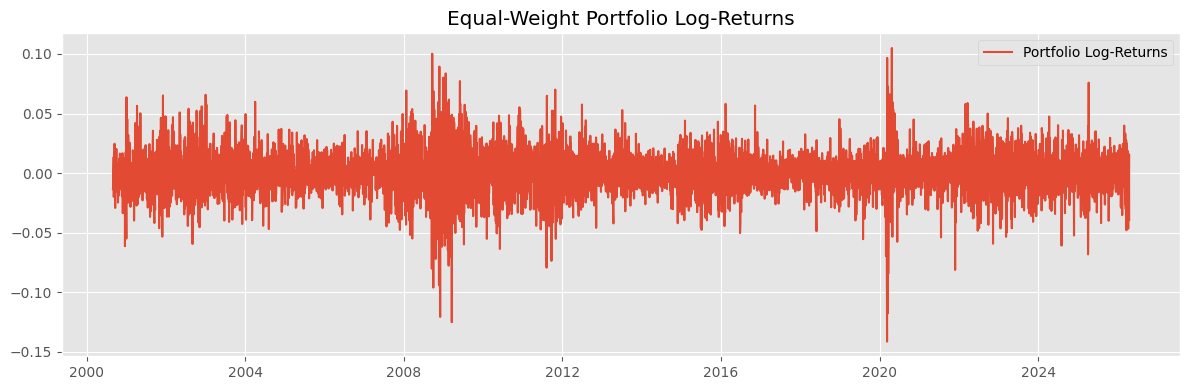

,r_p,var_p,vol_p
Date,,,
2022-09-12,0.017445,0.000499,0.022345
2022-09-13,-0.000756,0.000503,0.022420
2022-09-14,0.000424,0.000525,0.022915
2022-09-15,-0.005458,0.000517,0.022738
2022-09-16,-0.003579,0.000517,0.022745


In [13]:
w = torch.full((len(feature_cols),), 1.0 / len(feature_cols), dtype=torch.float32, device=device)
w_np = w.detach().cpu().numpy()

portfolio_logrets = torch.tensor(logret[feature_cols].values, dtype=torch.float32, device=device) @ w
portfolio_logrets_np = portfolio_logrets.detach().cpu().numpy()

plt.figure(figsize=(12, 4))
plt.plot(logret.index, portfolio_logrets_np, label="Portfolio Log-Returns")
plt.title("Equal-Weight Portfolio Log-Returns")
plt.legend()
plt.tight_layout()
plt.show()

portfolio_splits = build_portfolio_splits(sigma_splits, w_np)
portfolio_train = portfolio_splits["train"]
portfolio_val = portfolio_splits["val"]
portfolio_test = portfolio_splits["test"]

portfolio_test.head()


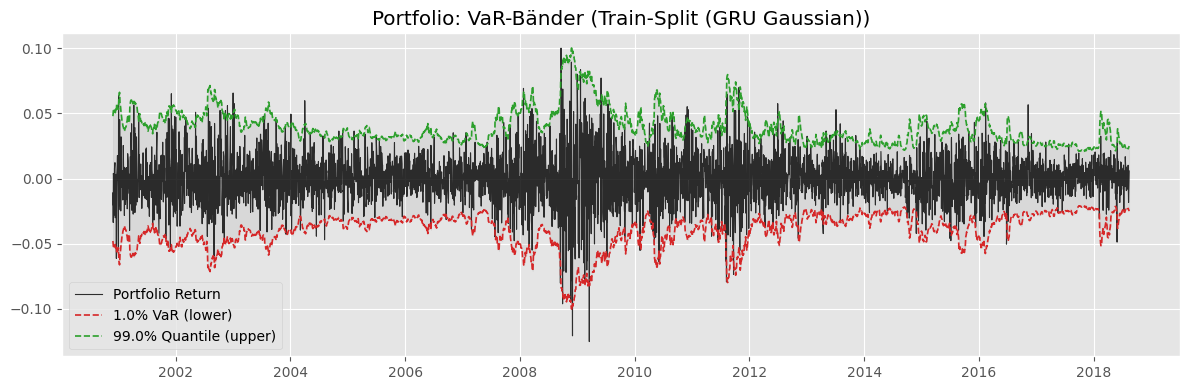

Portfolio hit rate = 1.264% (target 1.000%)


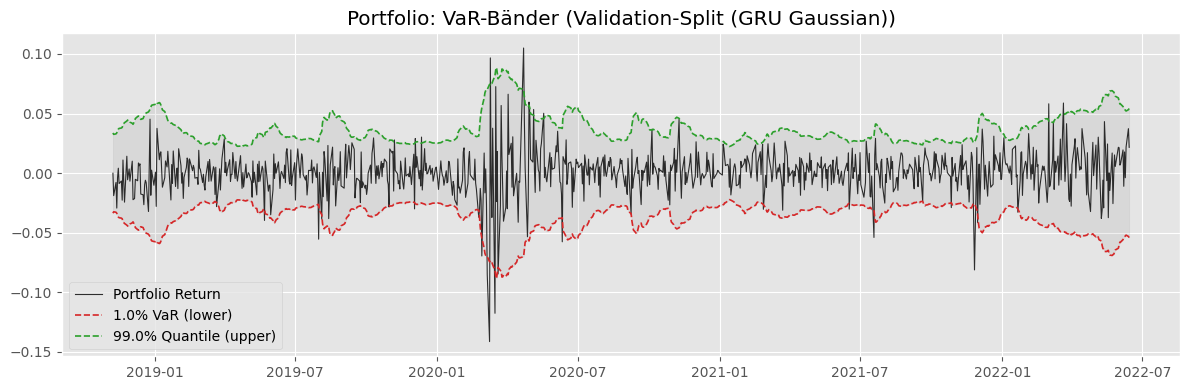

Portfolio hit rate = 2.326% (target 1.000%)


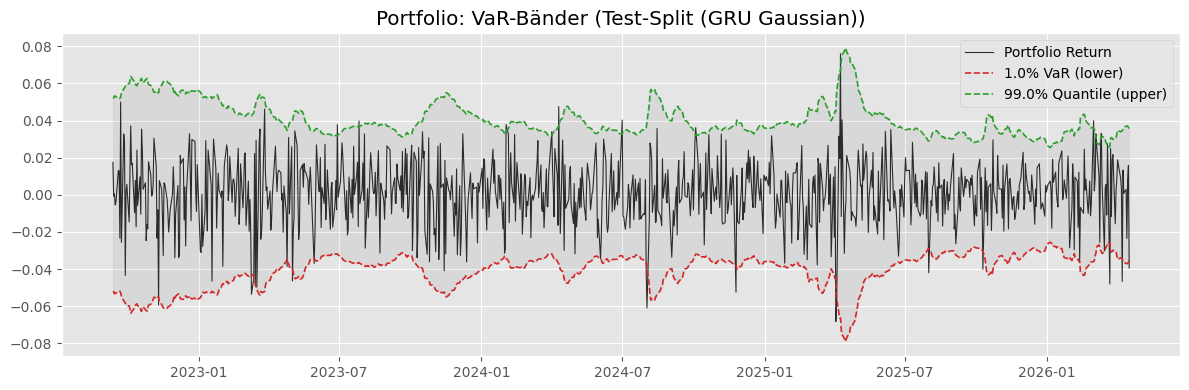

Portfolio hit rate = 1.883% (target 1.000%)


In [14]:
plot_var(alpha=0.01, lookback=lookback, view="Train-Split (GRU Gaussian)", portfolio=True, portfolio_df=portfolio_train)
plot_var(alpha=0.01, lookback=lookback, view="Validation-Split (GRU Gaussian)", portfolio=True, portfolio_df=portfolio_val)
plot_var(alpha=0.01, lookback=lookback, view="Test-Split (GRU Gaussian)", portfolio=True, portfolio_df=portfolio_test)


## GRU with Student-t NLL


In [15]:
student_loss = StudentTLoss(init_nu=8.0, min_nu=2.01, max_nu=100.0)
cov_model_t, hist_t, sigma_splits_t, y_splits_t = fit_gru_model(loss_fn=student_loss)

learned_nu = float(student_loss.nu.detach().cpu())
student_kwargs = {"nu": learned_nu}

sigma_train_real_t = sigma_splits_t["train"]
sigma_val_real_t = sigma_splits_t["val"]
sigma_test_real_t = sigma_splits_t["test"]

learned_nu


Epoch 001 | train NLL 5.538172 | val NLL 5.875277 | lr 1.00e-04
Epoch 002 | train NLL 5.387030 | val NLL 5.806323 | lr 1.00e-04
Epoch 003 | train NLL 5.285742 | val NLL 5.748512 | lr 1.00e-04
Epoch 004 | train NLL 5.212020 | val NLL 5.695984 | lr 1.00e-04
Epoch 005 | train NLL 5.154055 | val NLL 5.643143 | lr 1.00e-04
Epoch 006 | train NLL 5.117209 | val NLL 5.601013 | lr 1.00e-04
Epoch 007 | train NLL 5.083773 | val NLL 5.557562 | lr 1.00e-04
Epoch 008 | train NLL 5.039680 | val NLL 5.524725 | lr 9.99e-05
Epoch 009 | train NLL 5.006154 | val NLL 5.501207 | lr 9.99e-05
Epoch 010 | train NLL 4.980510 | val NLL 5.475728 | lr 9.99e-05
Epoch 011 | train NLL 4.977744 | val NLL 5.456646 | lr 9.99e-05
Epoch 012 | train NLL 4.965144 | val NLL 5.442740 | lr 9.99e-05
Epoch 013 | train NLL 4.963125 | val NLL 5.423744 | lr 9.98e-05
Epoch 014 | train NLL 4.953450 | val NLL 5.408324 | lr 9.98e-05
Epoch 015 | train NLL 4.944262 | val NLL 5.394924 | lr 9.98e-05
Epoch 016 | train NLL 4.938483 | val NLL

8.14438247680664

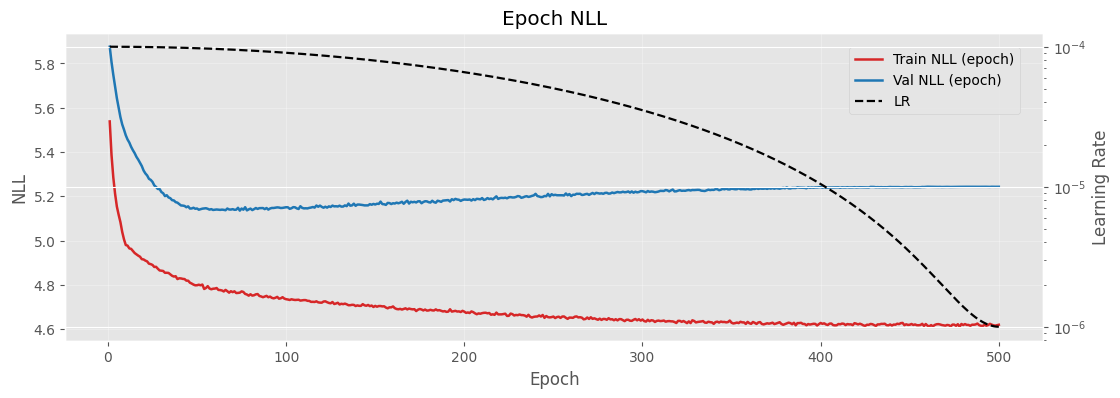

In [16]:
plot_loss(hist_t)


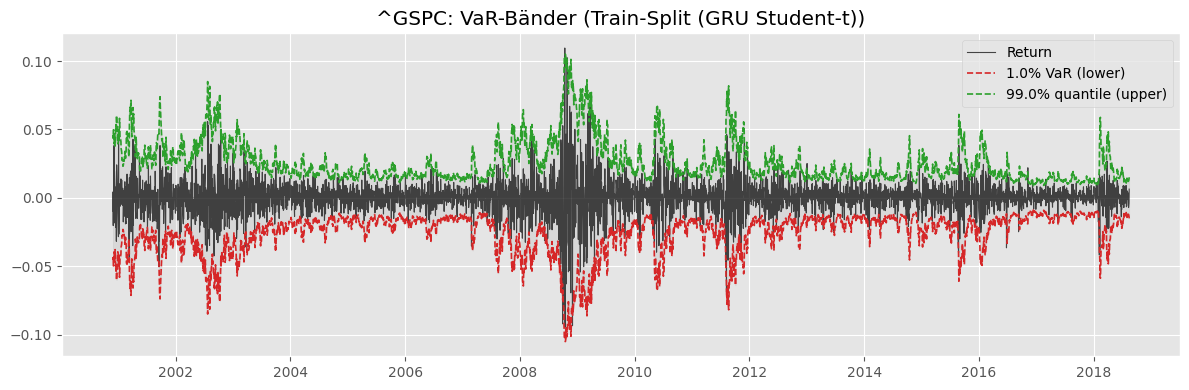

^GSPC: hit rate = 1.219% (target 1.000%)


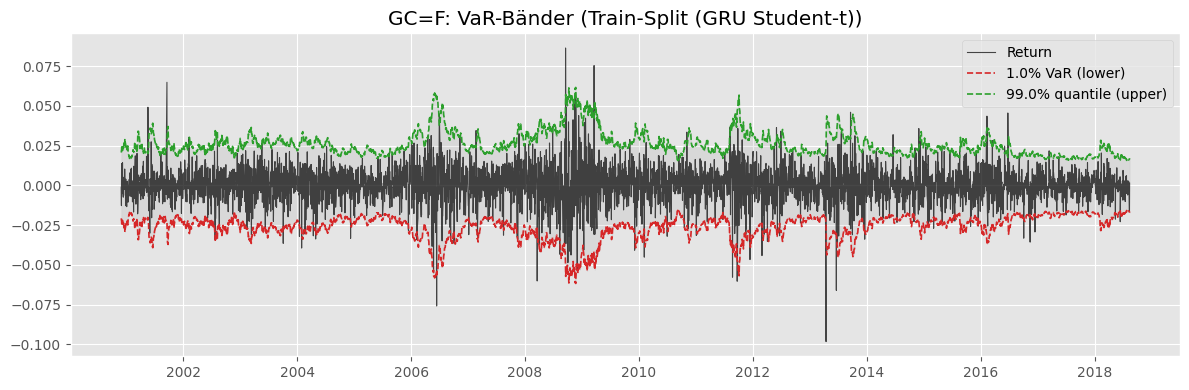

GC=F: hit rate = 1.332% (target 1.000%)


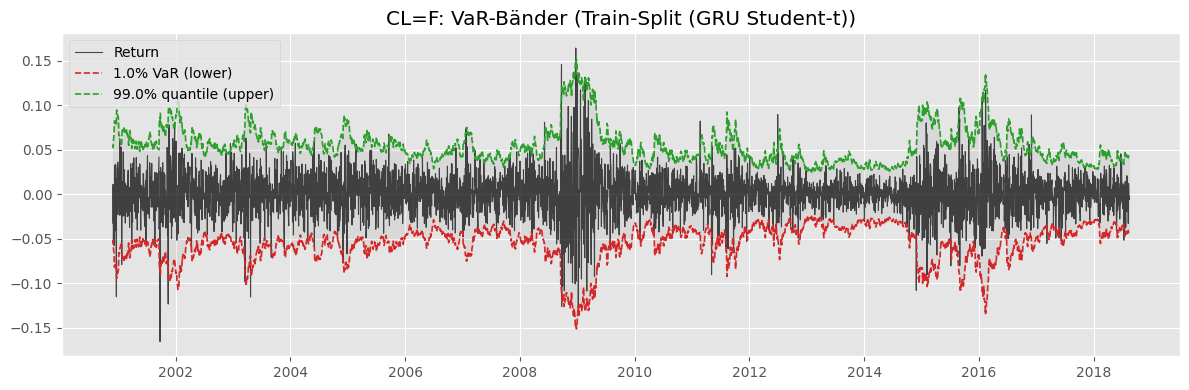

CL=F: hit rate = 1.151% (target 1.000%)


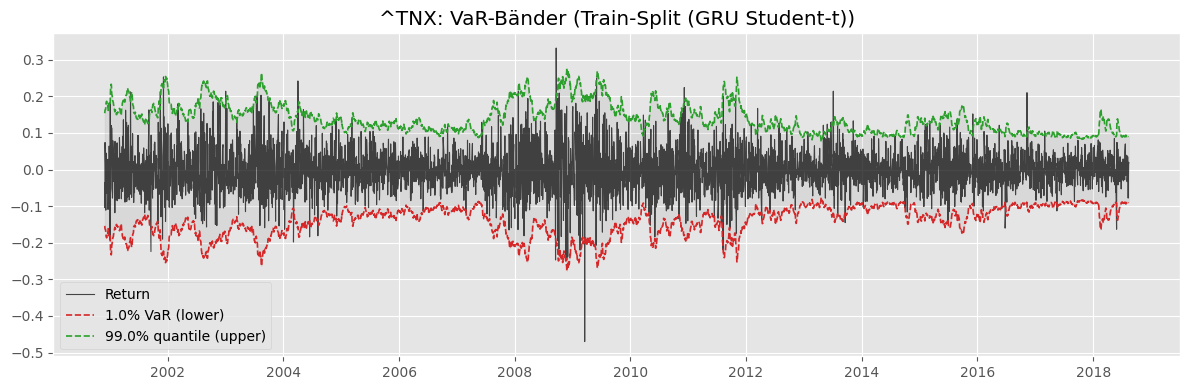

^TNX: hit rate = 0.564% (target 1.000%)


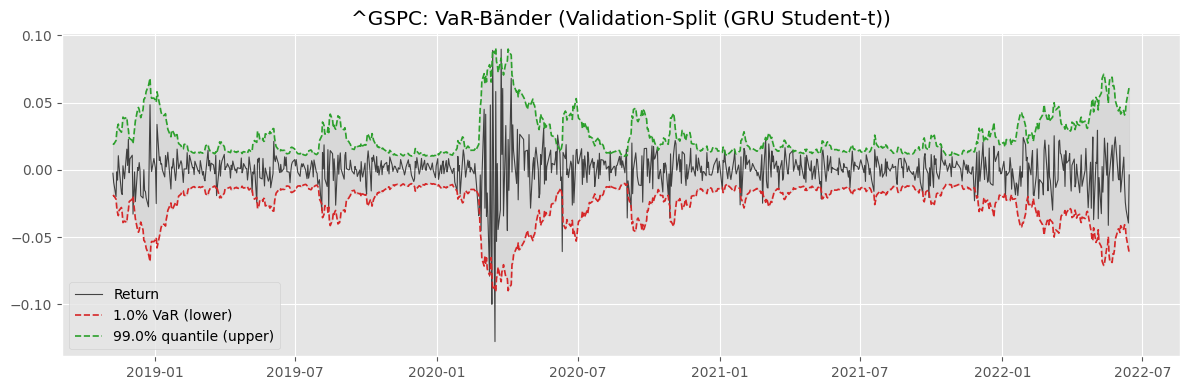

^GSPC: hit rate = 2.658% (target 1.000%)


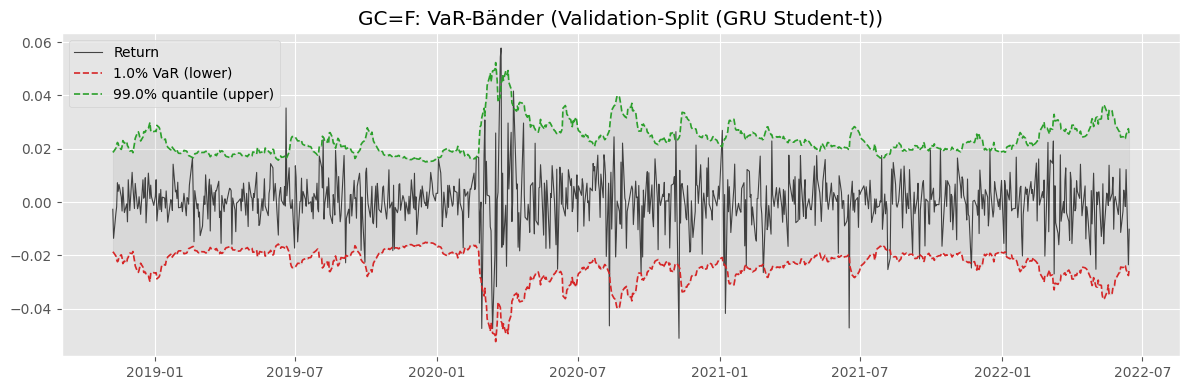

GC=F: hit rate = 1.661% (target 1.000%)


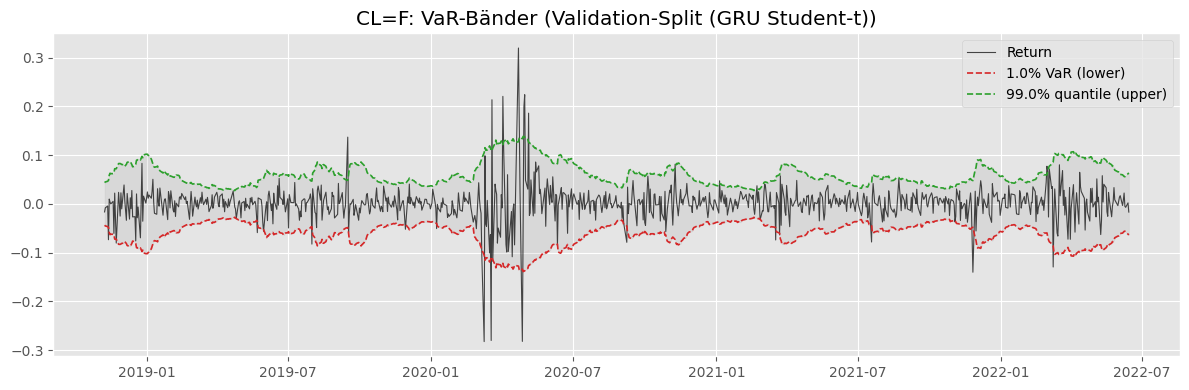

CL=F: hit rate = 2.326% (target 1.000%)


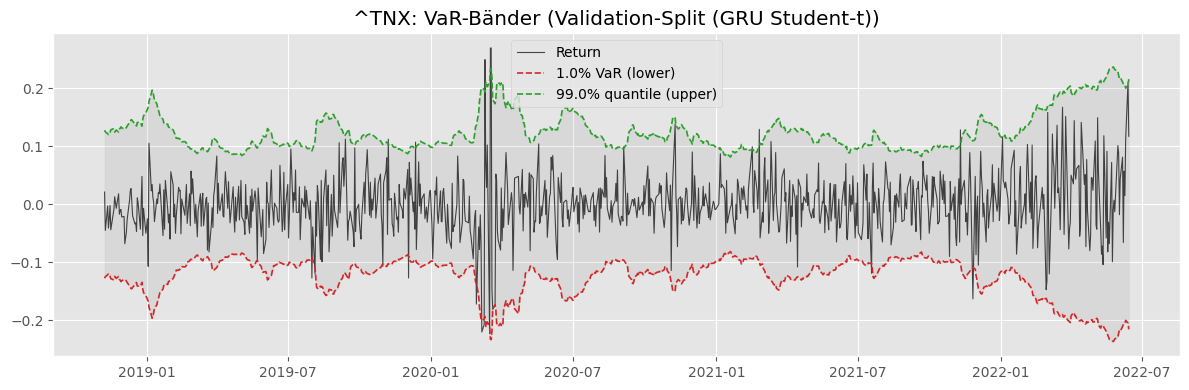

^TNX: hit rate = 1.440% (target 1.000%)


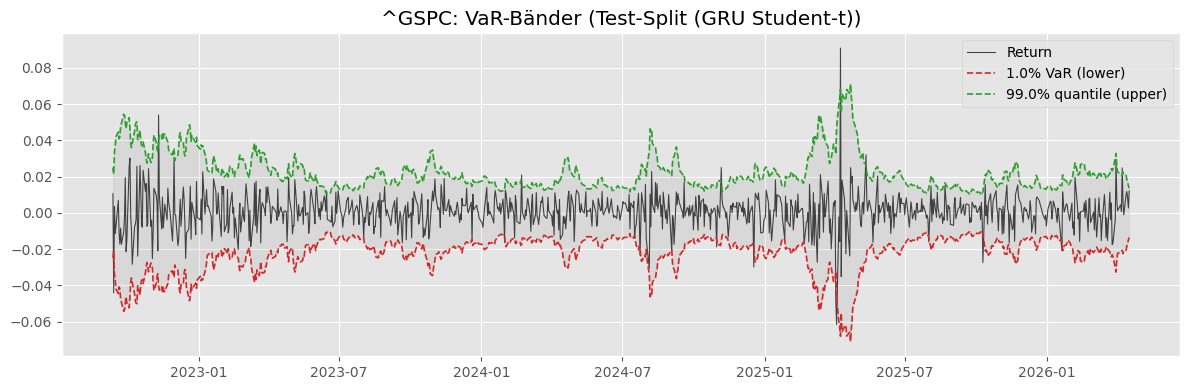

^GSPC: hit rate = 1.661% (target 1.000%)


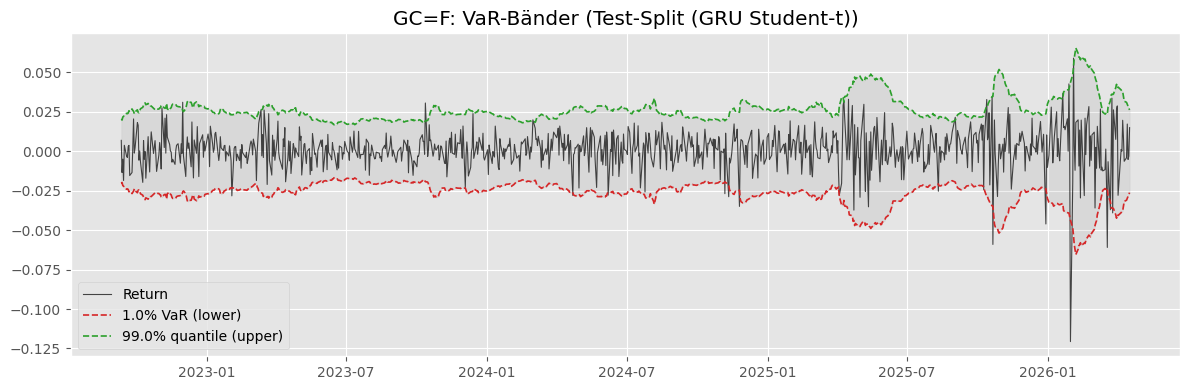

GC=F: hit rate = 1.550% (target 1.000%)


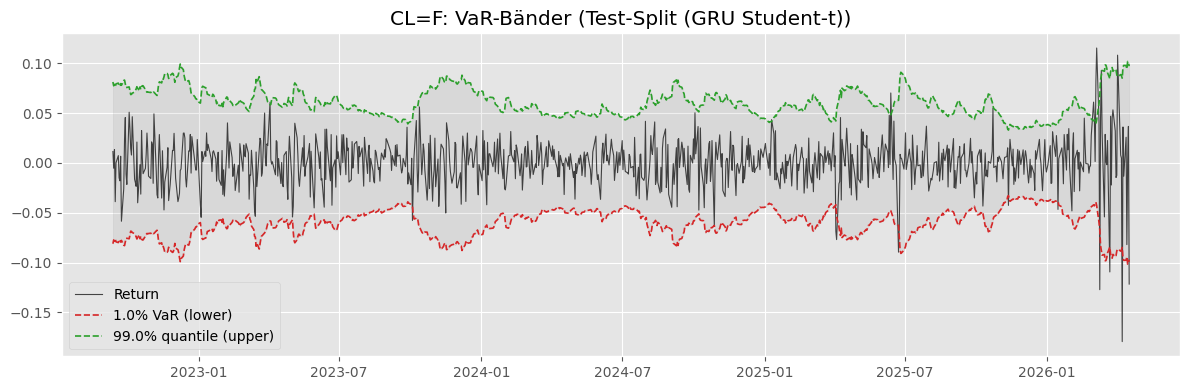

CL=F: hit rate = 1.218% (target 1.000%)


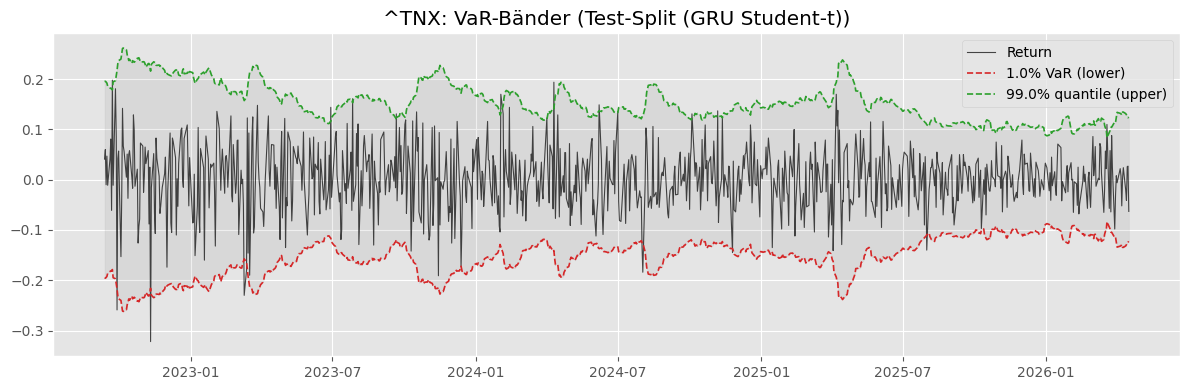

^TNX: hit rate = 0.997% (target 1.000%)


In [17]:
plot_var(alpha=0.01, lookback=lookback, cols=feature_cols, view="Train-Split (GRU Student-t)", df=train_df, pred_vol=sigma_train_real_t, loss_fn=student_nll, loss_kwargs=student_kwargs)
plot_var(alpha=0.01, lookback=lookback, cols=feature_cols, view="Validation-Split (GRU Student-t)", df=val_df, pred_vol=sigma_val_real_t, loss_fn=student_nll, loss_kwargs=student_kwargs)
plot_var(alpha=0.01, lookback=lookback, cols=feature_cols, view="Test-Split (GRU Student-t)", df=test_df, pred_vol=sigma_test_real_t, loss_fn=student_nll, loss_kwargs=student_kwargs)


## Portfolio (Student-t NLL)


In [18]:
portfolio_splits_t = build_portfolio_splits(sigma_splits_t, w_np)
portfolio_train_t = portfolio_splits_t["train"]
portfolio_val_t = portfolio_splits_t["val"]
portfolio_test_t = portfolio_splits_t["test"]

portfolio_test_t.head()


,r_p,var_p,vol_p
Date,,,
2022-09-12,0.017445,0.000489,0.022116
2022-09-13,-0.000756,0.000478,0.021875
2022-09-14,0.000424,0.000488,0.022085
2022-09-15,-0.005458,0.000478,0.021855
2022-09-16,-0.003579,0.000469,0.021649


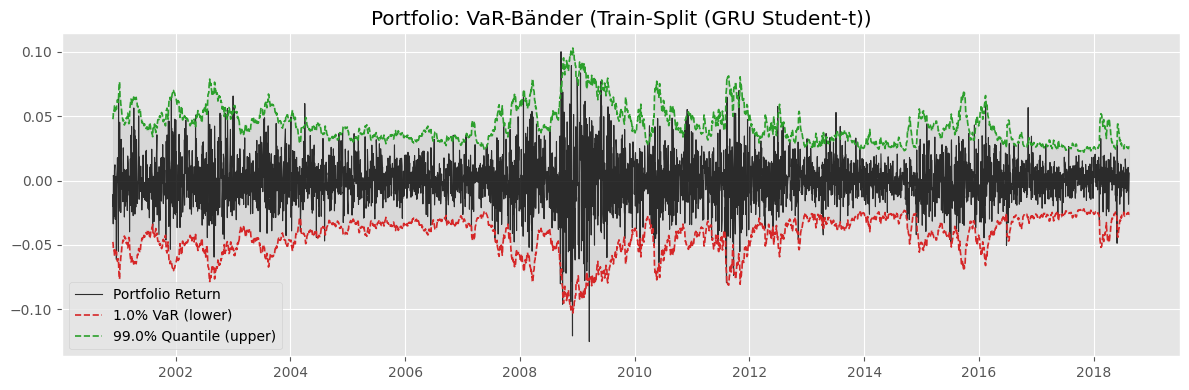

Portfolio hit rate = 0.722% (target 1.000%)


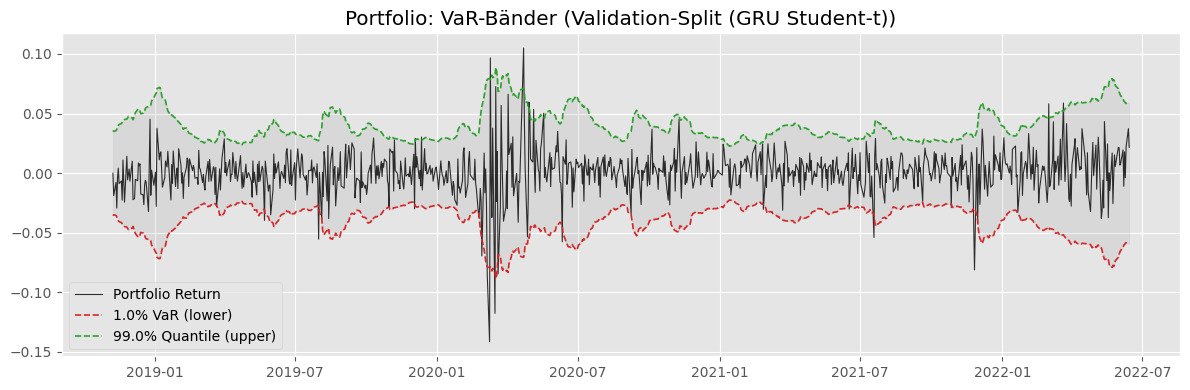

Portfolio hit rate = 1.993% (target 1.000%)


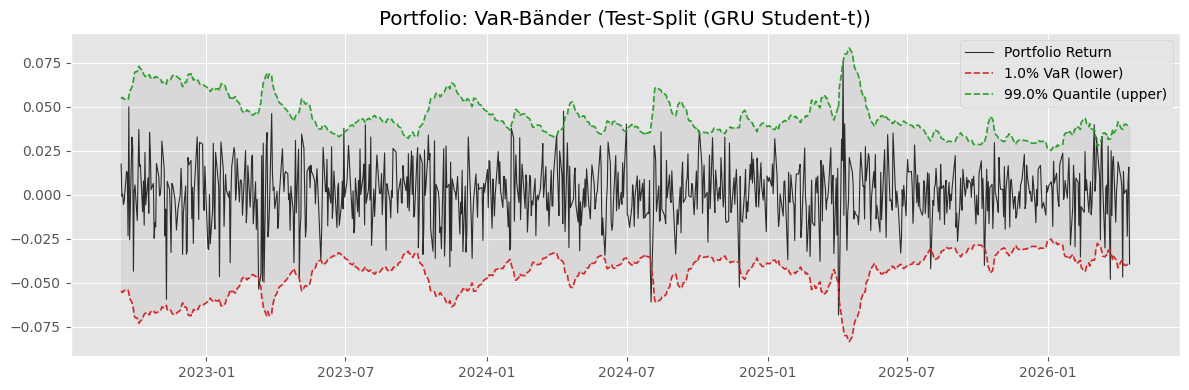

Portfolio hit rate = 1.107% (target 1.000%)


In [19]:
plot_var(alpha=0.01, lookback=lookback, view="Train-Split (GRU Student-t)", portfolio=True, portfolio_df=portfolio_train_t, loss_fn=student_nll, loss_kwargs=student_kwargs)
plot_var(alpha=0.01, lookback=lookback, view="Validation-Split (GRU Student-t)", portfolio=True, portfolio_df=portfolio_val_t, loss_fn=student_nll, loss_kwargs=student_kwargs)
plot_var(alpha=0.01, lookback=lookback, view="Test-Split (GRU Student-t)", portfolio=True, portfolio_df=portfolio_test_t, loss_fn=student_nll, loss_kwargs=student_kwargs)


## Filtered Historical Simulation


In [20]:
alpha = 0.01
window = 1000

fhs_normal = run_fhs_pipeline(portfolio_train, portfolio_val, portfolio_test, alpha=alpha, window=window)
var_fhs_train = fhs_normal["train"]["var"]
es_fhs_train = fhs_normal["train"]["es"]
hit_train = fhs_normal["train"]["hits"]

var_fhs_val = fhs_normal["val"]["var"]
es_fhs_val = fhs_normal["val"]["es"]
hit_val = fhs_normal["val"]["hits"]

var_fhs_test = fhs_normal["test"]["var"]
es_fhs_test = fhs_normal["test"]["es"]
hits_test = fhs_normal["test"]["hits"]

pd.DataFrame(
    {
        "hit_rate": [hit_train.mean(), hit_val.mean(), hits_test.mean()],
    },
    index=["train", "val", "test"],
)


,hit_rate
train,0.013116
val,0.017719
test,0.009967


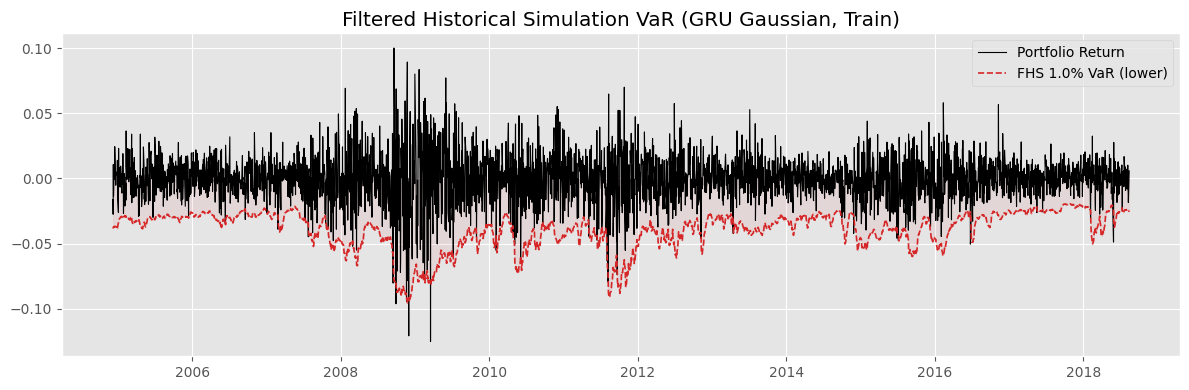

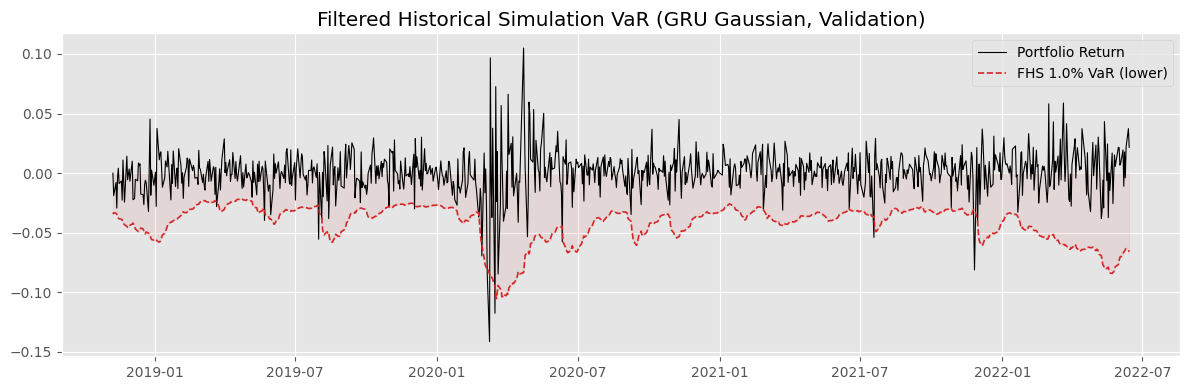

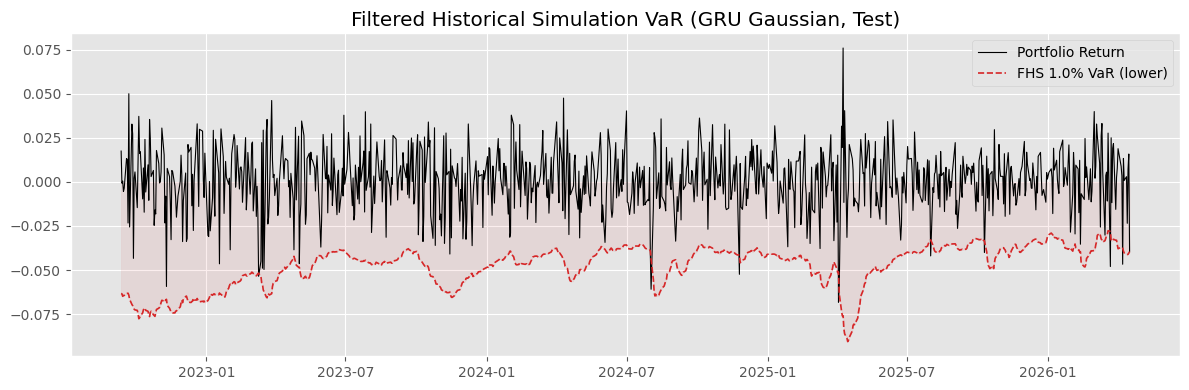

In [21]:
plot_fhs_var(
    portfolio_train,
    var_fhs_train,
    alpha=alpha,
    title="Filtered Historical Simulation VaR (GRU Gaussian, Train)",
    start=fhs_normal["burn_in"],
)
plot_fhs_var(
    portfolio_val,
    var_fhs_val,
    alpha=alpha,
    title="Filtered Historical Simulation VaR (GRU Gaussian, Validation)",
)
plot_fhs_var(
    portfolio_test,
    var_fhs_test,
    alpha=alpha,
    title="Filtered Historical Simulation VaR (GRU Gaussian, Test)",
)


In [22]:
fhs_student = run_fhs_pipeline(portfolio_train_t, portfolio_val_t, portfolio_test_t, alpha=alpha, window=window)
var_fhs_train_t = fhs_student["train"]["var"]
es_fhs_train_t = fhs_student["train"]["es"]
hit_train_t = fhs_student["train"]["hits"]

var_fhs_val_t = fhs_student["val"]["var"]
es_fhs_val_t = fhs_student["val"]["es"]
hit_val_t = fhs_student["val"]["hits"]

var_fhs_test_t = fhs_student["test"]["var"]
es_fhs_test_t = fhs_student["test"]["es"]
hits_test_t = fhs_student["test"]["hits"]

pd.DataFrame(
    {
        "hit_rate": [hit_train_t.mean(), hit_val_t.mean(), hits_test_t.mean()],
    },
    index=["train", "val", "test"],
)


,hit_rate
train,0.013699
val,0.018826
test,0.011074


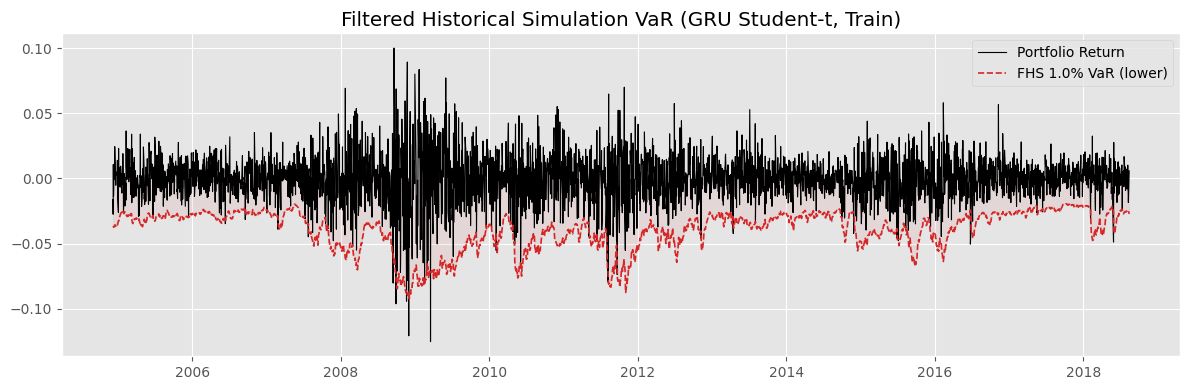

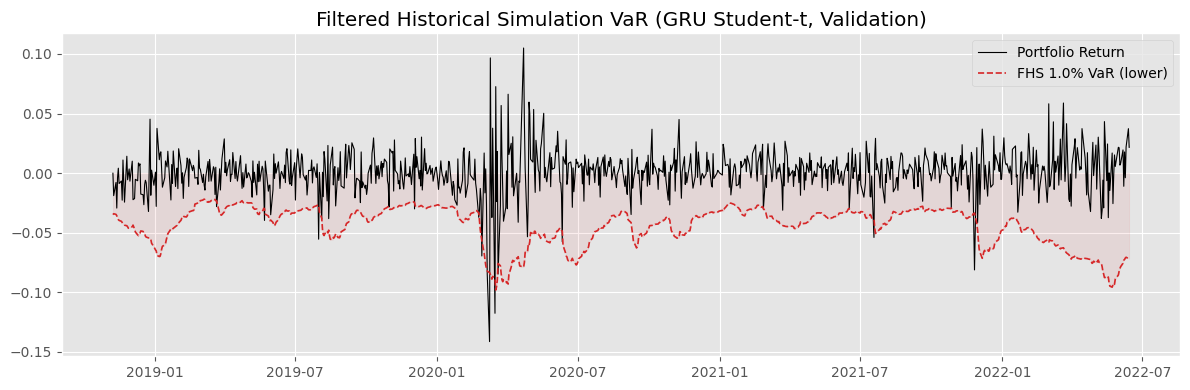

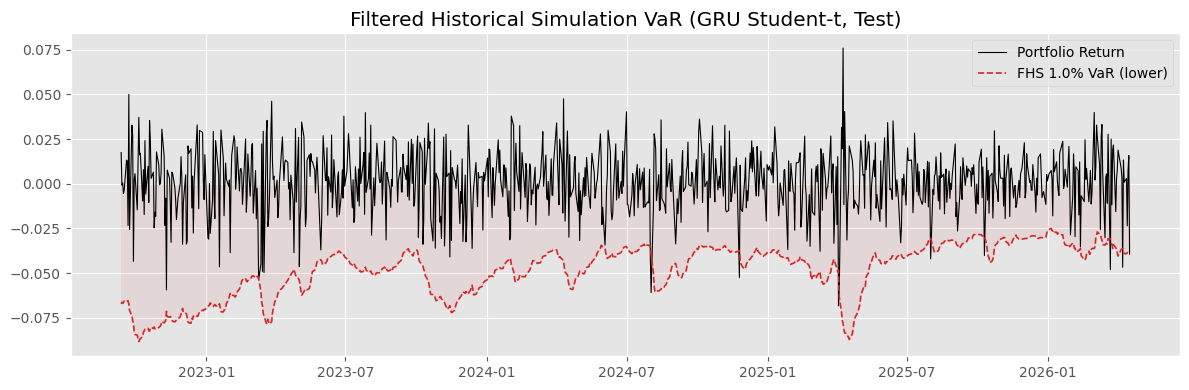

In [23]:
plot_fhs_var(
    portfolio_train_t,
    var_fhs_train_t,
    alpha=alpha,
    title="Filtered Historical Simulation VaR (GRU Student-t, Train)",
    start=fhs_student["burn_in"],
)
plot_fhs_var(
    portfolio_val_t,
    var_fhs_val_t,
    alpha=alpha,
    title="Filtered Historical Simulation VaR (GRU Student-t, Validation)",
)
plot_fhs_var(
    portfolio_test_t,
    var_fhs_test_t,
    alpha=alpha,
    title="Filtered Historical Simulation VaR (GRU Student-t, Test)",
)


## Backtesting


In [24]:
results = run_backtest_suite(
    returns=portfolio_test["r_p"].values,
    var=var_fhs_test,
    es=es_fhs_test,
    alpha=alpha,
    volatility=portfolio_test["vol_p"].values,
)

results_student = run_backtest_suite(
    returns=portfolio_test_t["r_p"].values,
    var=var_fhs_test_t,
    es=es_fhs_test_t,
    alpha=alpha,
    volatility=portfolio_test_t["vol_p"].values,
)

{
    "gru_gaussian": results,
    "gru_student_t": results_student,
}


{'gru_gaussian': {'meta': {'alpha': 0.01, 'n_obs': 903},
  'var': {'kupiec': {'test': 'kupiec_uc',
    'alpha': 0.01,
    'n_obs': 903,
    'n_exceptions': 9,
    'expected_exceptions': 9.03,
    'hit_rate': 0.009966777408637873,
    'lr_uc': 0.00010078506586808089,
    'p_value': 0.991990030572733},
   'christoffersen': {'test': 'christoffersen_cc',
    'alpha': 0.01,
    'n_obs': 903,
    'n_exceptions': 9,
    'hit_rate': 0.009966777408637873,
    'transition_counts': {'n00': 885, 'n01': 8, 'n10': 8, 'n11': 1},
    'transition_probs': {'pi_01': 0.008958566629339306,
     'pi_11': 0.1111111111111111,
     'pi_pooled': 0.009977827050997782},
    'lr_ind': 3.1935035158045366,
    'p_value_ind': 0.07393140570219324,
    'lr_uc': 0.00010078506586808089,
    'lr_cc': 3.1936043008704047,
    'p_value_cc': 0.20254318610945155}},
  'cc': {'pvalue_twosided_simple': 0.0054570902948795075,
   'pvalue_onesided_simple': 1.0,
   'pvalue_twosided_general': 0.5405068949558721,
   'pvalue_onesided_ge